In [42]:
import pandas as pd

In [43]:
macro_training_data = pd.read_csv("macro_training_data_features.csv",parse_dates=["aligned_date"])
sentiment_training_data = pd.read_csv("sentiment_training_data_features.csv",parse_dates=["aligned_date"])
all_feature_data = pd.merge(
    sentiment_training_data, 
    macro_training_data, 
    on='aligned_date', 
    how='inner'
)
all_feature_data

,aligned_date,Pos_Score_30day_EMA,Neg_Score_30day_EMA,Neutrality_Ratio_30day_EMA,period_rolling_recession,recession,CPIAUCSL,PAYEMS,UNRATE,INDPRO,...,UMCSENT_MoM,UMCSENT_YoY,UNRATE_MoM_diff,UNRATE_YoY_diff,T10Y3M_MoM_diff,T10Y3M_YoY_diff,T10Y2Y_MoM_diff,T10Y2Y_YoY_diff,BAA10Y_MoM_diff,BAA10Y_YoY_diff
0,2008-03-01,0.124942,0.459353,0.295600,1.0,1.0,212.516,138102.0,4.9,114.2334,...,-0.062252,-0.231270,0.2,0.5,1.00,2.25,0.89,2.04,0.70,1.58
1,2008-04-01,0.142335,0.497481,0.299145,1.0,1.0,212.571,137993.0,4.8,113.6597,...,-0.018362,-0.242094,-0.1,0.3,0.39,2.38,-0.05,1.94,0.23,1.81
2,2008-05-01,0.139617,0.478218,0.310837,1.0,1.0,213.301,137846.0,5.1,112.1281,...,-0.099281,-0.353973,0.3,0.5,0.27,2.94,-0.35,1.57,-0.35,1.50
3,2008-06-01,0.157693,0.448432,0.363876,1.0,1.0,213.743,137818.0,5.0,111.1807,...,-0.044728,-0.323529,-0.1,0.5,-0.17,2.56,-0.08,1.33,-0.10,1.25
4,2008-07-01,0.145640,0.478335,0.356198,1.0,1.0,215.132,137754.0,5.5,110.9051,...,-0.056856,-0.352468,0.5,1.1,-0.08,2.37,-0.04,1.33,0.05,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2023-11-01,0.205041,0.452301,0.319152,0.0,0.0,307.481,156874.0,3.8,103.6115,...,-0.060383,0.065109,0.0,0.3,0.25,-0.59,0.25,0.22,0.07,-0.43
176,2023-12-01,0.288294,0.368613,0.436345,0.0,0.0,307.619,156923.0,3.9,102.7081,...,-0.039185,0.079225,0.1,0.2,-0.37,-0.39,-0.17,0.34,-0.18,-0.48
177,2024-01-01,0.320061,0.304784,0.513559,0.0,0.0,307.917,157087.0,3.7,102.6651,...,0.137031,0.167504,-0.2,0.0,-0.44,-0.98,0.01,0.18,-0.06,-0.38
178,2024-03-01,0.341223,0.302135,0.523062,0.0,0.0,309.685,157700.0,3.7,102.5739,...,0.133429,0.217257,0.0,0.2,0.32,-0.02,-0.04,0.30,-0.06,-0.35


Text(0, 0.5, 'Correlation Value')

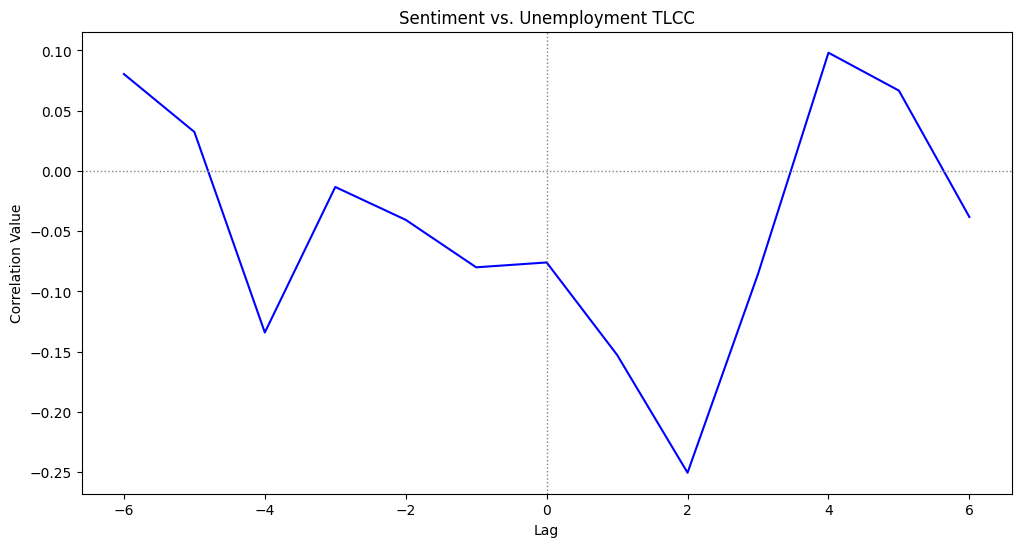

In [44]:
temp_df = all_feature_data[['UNRATE_MoM_diff']].copy()

for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    temp_df[col_name] = all_feature_data['Neutrality_Ratio_30day_EMA'].shift(lag)

temp_df = temp_df.dropna()

correlations = []
for lag in range(-6, 7):
    col_name = f'sent_lag_{lag}'
    corr_value = temp_df[col_name].corr(temp_df['UNRATE_MoM_diff'])
    correlations.append([lag, corr_value])
df = pd.DataFrame(correlations, columns = ['Lag', 'Correlation Value']) 

from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Lag'], df['Correlation Value'], 
         label='Sentiment vs. Unemployment TLCC', color='blue')
plt.axhline(y=0, color='grey', linestyle=':', linewidth=1, label="Neutral Correlation")
plt.axvline(x=0, color='grey', linestyle=':', linewidth=1, label="Neutral Lag")
plt.title('Sentiment vs. Unemployment TLCC')
plt.xlabel('Lag')
plt.ylabel('Correlation Value')

The peak occurs at around a lag of 4 base on the following two factors:
- UNRATE_MoM_diff (Hard Data): Did the unemployment rate go up or down this month?
- Neutrality_Ratio_30day_EMA (Soft Data): Are the financial news headlines leaning positive or negative this month?

So based on this graph: Sentiment from 4 months ago is the best match for the Unemployment changes happening today.

To directly answers your Phase 3 objective: Does the crowd anticipate the data, or react to it?
- A peak at Lag = +4 provides quantitative proof that Sentiment LEADS the hard data by 4 months.

But we have to note that **Correlation of continuous signals (movements) is NOT the same as predicting a binary event (a recession).** 

In [45]:
import joblib
from sklearn.calibration import CalibratedClassifierCV
from datetime import datetime
macro_model = joblib.load('hard_model.joblib')
sentiment_model = joblib.load('soft_model.joblib')
scaler = joblib.load('scaler.joblib')

In [46]:
macro_training_unseen = macro_training_data[(macro_training_data["aligned_date"]>=datetime(2018,1,1))& (macro_training_data["aligned_date"]<= datetime(2024,1,1))]
macro_training_unseen_y = macro_training_unseen['target']
macro_training_unseen_x = macro_training_unseen.drop(columns=['recession','target','aligned_date','recession',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M", "T10Y2Y", "BAA10Y","UMCSENT"])
macro_training_unseen_x = scaler.transform(macro_training_unseen_x)
sentiment_training_unseen = pd.merge(
    macro_training_unseen['aligned_date'] ,
    sentiment_training_data, 
    on='aligned_date', 
    how='inner'
)
sentiment_training_unseen_y = sentiment_training_unseen['period_rolling_recession']
sentiment_training_unseen_x = sentiment_training_unseen.drop(columns=['period_rolling_recession','aligned_date'])
print("macro:",len(macro_training_unseen),"soft:",len(sentiment_training_unseen))

macro: 68 soft: 68


In [47]:
proba_table = macro_training_unseen[['aligned_date','recession']].copy()

# Ensure we use the exact columns the scaler expects to maintain feature names
# This matches the drop logic used in Cell 27
X_unseen = macro_training_unseen.drop(columns=['recession','target','aligned_date',"CPIAUCSL", "PAYEMS", "INDPRO", "UNRATE", "T10Y3M", "T10Y2Y", "BAA10Y","UMCSENT"])

# Transform and keep as a DataFrame to satisfy the feature names check
macro_training_unseen_x_scaled = pd.DataFrame(
    scaler.transform(X_unseen), 
    columns=X_unseen.columns, 
    index=X_unseen.index
)

# Generate probabilities using the base macro_model
macro_proba = macro_model.predict_proba(macro_training_unseen_x_scaled)[:,1]

# Generate probabilities for the base sentiment_model
sentiment_proba = sentiment_model.predict_proba(sentiment_training_unseen_x)[:,1]

proba_table["macro_probability"] = macro_proba
proba_table["sentiment_probability"] = sentiment_proba

Using rank averageing
* Instead of averaging the raw probability numbers (like $0.15$ and $0.85$), convert those probabilities into ranks. For example, in a dataset of 100 months, the month the model is most certain is a recession gets a rank of 100, and the least certain gets a rank of 1. You then average these rank positions across your models.


In [48]:
from scipy.stats import rankdata
import matplotlib.pyplot as plt

proba_table["macro_rank"] = rankdata(proba_table["macro_probability"])
proba_table["sentiment_rank"] = rankdata(proba_table["sentiment_probability"])
proba_table["ensemble_rank_avg"] = (proba_table["macro_rank"] + proba_table["sentiment_rank"]) / 2
max_rank = len(proba_table)
proba_table["rank_avg_probability"] = proba_table["ensemble_rank_avg"] / max_rank

In [49]:
proba_table.head(20)

,aligned_date,recession,macro_probability,sentiment_probability,macro_rank,sentiment_rank,ensemble_rank_avg,rank_avg_probability
184,2018-01-01,0.0,0.008966,0.055291,6.5,27.5,17.00,0.250000
185,2018-02-01,0.0,0.012518,0.055291,11.0,27.5,19.25,0.283088
186,2018-04-01,0.0,0.013347,0.001108,16.0,2.0,9.00,0.132353
187,2018-05-01,0.0,0.008717,0.001863,5.0,6.0,5.50,0.080882
188,2018-06-01,0.0,0.007887,0.055291,1.0,27.5,14.25,0.209559
189,2018-07-01,0.0,0.008416,0.055291,4.0,27.5,15.75,0.231618
190,2018-08-01,0.0,0.008966,0.055291,6.5,27.5,17.00,0.250000
191,2018-09-01,0.0,0.008091,0.055291,2.0,27.5,14.75,0.216912
192,2018-10-01,0.0,0.009198,0.055291,8.0,27.5,17.75,0.261029
193,2018-11-01,0.0,0.008124,0.988752,3.0,65.0,34.00,0.500000


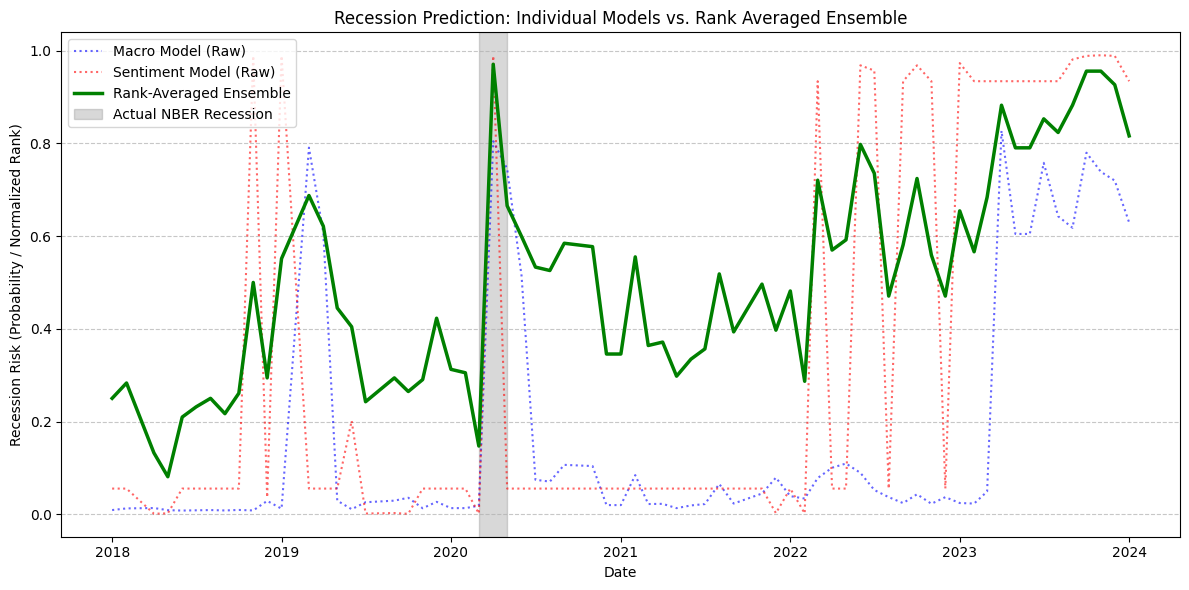

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(proba_table['aligned_date'], proba_table['macro_probability'], 
         label='Macro Model (Raw)', color='blue', linestyle=':', alpha=0.6)
plt.plot(proba_table['aligned_date'], proba_table['sentiment_probability'], 
         label='Sentiment Model (Raw)', color='red', linestyle=':', alpha=0.6)
plt.plot(proba_table['aligned_date'], proba_table['rank_avg_probability'], 
         label='Rank-Averaged Ensemble', color='green', linewidth=2.5)
for i, (s, e) in enumerate(zip(starts, ends)):
    plt.axvspan(s, e, color='gray', alpha=0.3, label='Actual NBER Recession' if i == 0 else "")

plt.title('Recession Prediction: Individual Models vs. Rank Averaged Ensemble')
plt.xlabel('Date')
plt.ylabel('Recession Risk (Probability / Normalized Rank)')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()